# Diarka QAOA Portfolio — Notebook 04: Parameter Landscape at p = 1

**Week 3, Session 1.** Goal: visualise the QAOA cost surface that COBYLA had to navigate in Session 3.

At depth $p = 1$ the QAOA expectation value $\langle H \rangle (\gamma, \beta)$ is a smooth function of two real parameters, so we can sweep it directly on a 2-D grid and *see* the landscape COBYLA was optimising over. That gives us three things:

1. **A visual demonstration that QAOA is genuinely a hybrid algorithm.** The classical optimiser isn't a black box — it's navigating a cost surface whose structure we can characterise and reason about.
2. **The true global minimum on the $(\gamma, \beta)$ grid** — a tighter benchmark for the COBYLA result than the ground-state energy alone (since QAOA at $p = 1$ can't generally reach the ground state on a non-trivial problem).
3. **One striking image** that compresses an algorithmic story into a single shareable artefact, suitable for the blog post and a LinkedIn carousel slide.

The same machinery generalises to higher $p$ — we just lose the ability to plot, and have to take 2-D slices through the higher-dimensional surface.

## 0. Setup and load prior outputs

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import warnings

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

warnings.filterwarnings("ignore", category=Warning, module="scipy")

from qiskit.quantum_info import SparsePauliOp
from src.landscape import sweep_p1, slice_along_gamma, slice_along_beta

DATA_PROCESSED = ROOT / "data" / "processed"

# Reconstruct the cost Hamiltonian saved by Session 2.
ham_data = np.load(DATA_PROCESSED / "hamiltonian.npz", allow_pickle=False)
H = SparsePauliOp.from_list(list(zip(ham_data["pauli_labels"], ham_data["pauli_coeffs"])))
ISING_OFFSET = float(ham_data["ising_offset"])
E_GROUND     = float(ham_data["ground_energy"])
ENERGIES     = ham_data["sorted_energies"]
E_MAX        = float(ENERGIES[-1])

# Pull the COBYLA-converged (γ, β) from Session 3.
qaoa_data = np.load(DATA_PROCESSED / "qaoa_simulator_results.npz", allow_pickle=False)
COBYLA_PARAMS  = qaoa_data["p1_params"]    # [γ, β]
COBYLA_ENERGY  = float(qaoa_data["p1_energy"])
GAMMA_COBYLA   = float(COBYLA_PARAMS[0])
BETA_COBYLA    = float(COBYLA_PARAMS[1])

print(f"Cost Hamiltonian:      {len(H)} Pauli terms on {H.num_qubits} qubits")
print(f"Ground-state energy:   {E_GROUND:+.4f}")
print(f"Highest energy:        {E_MAX:+.4f}")
print(f"COBYLA result at p=1:  γ = {GAMMA_COBYLA:+.4f}, β = {BETA_COBYLA:+.4f}, ⟨H⟩ = {COBYLA_ENERGY:+.4f}")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

Cost Hamiltonian:      36 Pauli terms on 8 qubits
Ground-state energy:   -1.4436
Highest energy:        +8.1419
COBYLA result at p=1:  γ = +0.5112, β = +1.3395, ⟨H⟩ = -0.8845


## 1. What we're computing

At $p = 1$ the QAOA state is

$$|\psi(\gamma, \beta)\rangle \;=\; e^{-i\beta \sum_i X_i}\, e^{-i\gamma \hat H}\, |{+}\rangle^{\otimes n}$$

and the expectation value is

$$E(\gamma, \beta) \;=\; \langle \psi(\gamma, \beta) | \hat H | \psi(\gamma, \beta) \rangle$$

We sweep this on a regular grid. Default ranges:

- $\gamma \in [0, \pi]$ — one half of $e^{-i\gamma H}$'s natural $[0, 2\pi)$ period (the landscape has a $\gamma \to -\gamma$ symmetry up to mixer reflection).
- $\beta \in [0, \pi/2]$ — natural half-period of $R_X(2\beta)$.

For an $n = 8$ qubit problem the underlying statevector has only 256 complex amplitudes, so each grid point is essentially free to evaluate (no quantum circuit transpilation needed — we go straight through numpy). A $50 \times 50$ sweep finishes in well under a second on the laptop.

`src/landscape.py` implements this directly: the cost evolution $e^{-i\gamma H}$ is a per-element multiply (since the Ising $H$ is diagonal in the computational basis), and the mixer $e^{-i\beta \sum X_i}$ is applied qubit-by-qubit via a reshape trick, costing $O(n \cdot 2^n)$ per evaluation.

## 2. Sweep the landscape

In [2]:
import time

t0 = time.time()
land = sweep_p1(H, n_gamma=80, n_beta=80)
print(f"80×80 sweep: {time.time() - t0:.2f} s")

i, j, gamma_grid, beta_grid, energy_grid = land.argmin()
print()
print(f"Grid range:    γ ∈ [{land.gammas.min():.3f}, {land.gammas.max():.3f}]  "
      f"β ∈ [{land.betas.min():.3f}, {land.betas.max():.3f}]")
print(f"Energy range:  [{land.energies.min():+.4f}, {land.energies.max():+.4f}]")
print(f"Grid minimum:  γ = {gamma_grid:+.4f}, β = {beta_grid:+.4f}, ⟨H⟩ = {energy_grid:+.4f}")
print()
print(f"COBYLA result: γ = {GAMMA_COBYLA:+.4f}, β = {BETA_COBYLA:+.4f}, ⟨H⟩ = {COBYLA_ENERGY:+.4f}")
print(f"Gap (COBYLA − grid):  {COBYLA_ENERGY - energy_grid:+.6f}")

80×80 sweep: 0.46 s

Grid range:    γ ∈ [0.000, 3.142]  β ∈ [0.000, 1.571]
Energy range:  [-0.8832, +4.5600]
Grid minimum:  γ = +0.5170, β = +1.3322, ⟨H⟩ = -0.8832

COBYLA result: γ = +0.5112, β = +1.3395, ⟨H⟩ = -0.8845
Gap (COBYLA − grid):  -0.001292


## 3. The headline plot — energy landscape with COBYLA's path

The colormap shows $\langle H \rangle (\gamma, \beta)$ over the swept region. Lower is better (toward purple/black in viridis). The red star marks where COBYLA converged; the white circle marks the lowest energy on the discrete grid.

If the two are visually coincident, COBYLA found the global minimum at p=1. If they're far apart, COBYLA landed in a local minimum, which is one of QAOA's well-known failure modes at low depth and is itself an interesting story.

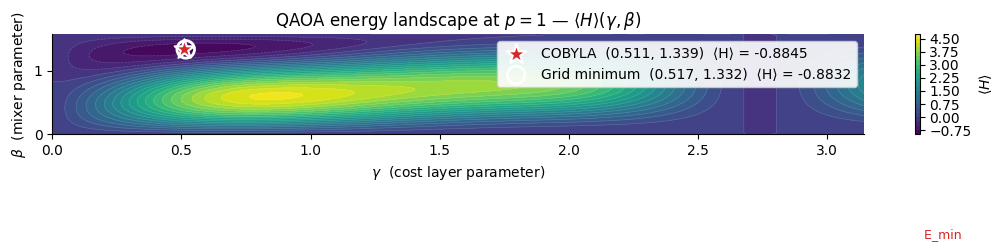

In [3]:
fig, ax = plt.subplots(figsize=(11, 7))

G, B = np.meshgrid(land.gammas, land.betas, indexing="ij")
levels = 25

cf = ax.contourf(G, B, land.energies, levels=levels, cmap="viridis")
contours = ax.contour(G, B, land.energies, levels=levels, colors="white", alpha=0.15, linewidths=0.5)

# COBYLA-converged point.
ax.scatter([GAMMA_COBYLA], [BETA_COBYLA],
           s=220, marker="*", color="#d62728", edgecolor="white", linewidth=1.5,
           zorder=10, label=f"COBYLA  ({GAMMA_COBYLA:.3f}, {BETA_COBYLA:.3f})  ⟨H⟩ = {COBYLA_ENERGY:+.4f}")

# Grid minimum.
ax.scatter([gamma_grid], [beta_grid],
           s=160, marker="o", facecolor="none", edgecolor="white", linewidth=2.0,
           zorder=11, label=f"Grid minimum  ({gamma_grid:.3f}, {beta_grid:.3f})  ⟨H⟩ = {energy_grid:+.4f}")

ax.set_xlabel(r"$\gamma$  (cost layer parameter)")
ax.set_ylabel(r"$\beta$  (mixer parameter)")
ax.set_title(r"QAOA energy landscape at $p = 1$ — $\langle H \rangle(\gamma, \beta)$")
cbar = plt.colorbar(cf, ax=ax, label=r"$\langle H \rangle$")
cbar.ax.axhline(E_GROUND, color="#d62728", lw=1.5, alpha=0.7)
cbar.ax.text(1.05, E_GROUND, " E_min", color="#d62728", va="center",
             transform=cbar.ax.get_yaxis_transform(), fontsize=9)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

### Reading the heatmap

A few things worth pointing out:

- **The dark "valley"** — a band where $\langle H \rangle$ is lowest. This is where any well-initialised classical optimiser should land.
- **The bright peaks** — regions where $\langle H \rangle$ rises *above* the random-circuit expectation. These are configurations that actively concentrate amplitude on *high-energy* bitstrings; QAOA can be misused to find the *worst* answer just as easily as the best one.
- **The ground state energy** is marked on the colorbar (red line). Note that even the deepest point of the landscape sits well above it — that's the $p = 1$ ceiling. To approach the ground state we need more layers.
- **The COBYLA star and the grid-minimum circle** should be in the same valley. If they are, COBYLA did its job; if they're separated, COBYLA either landed in a local minimum or our grid is too coarse.

## 4. One-dimensional slices through the optimum

Cutting the landscape along $\beta = \beta^\star$ (with $\gamma$ varying) and along $\gamma = \gamma^\star$ (with $\beta$ varying) gives two clean cross-sections. These show:

- The local curvature around the optimum — sharper curvature means more sensitivity to parameter noise, which matters when we move to hardware.
- The existence (or absence) of nearby local minima along each axis.

Below we slice through the *grid* minimum (more reliable than COBYLA's reported point, which could be off the grid).

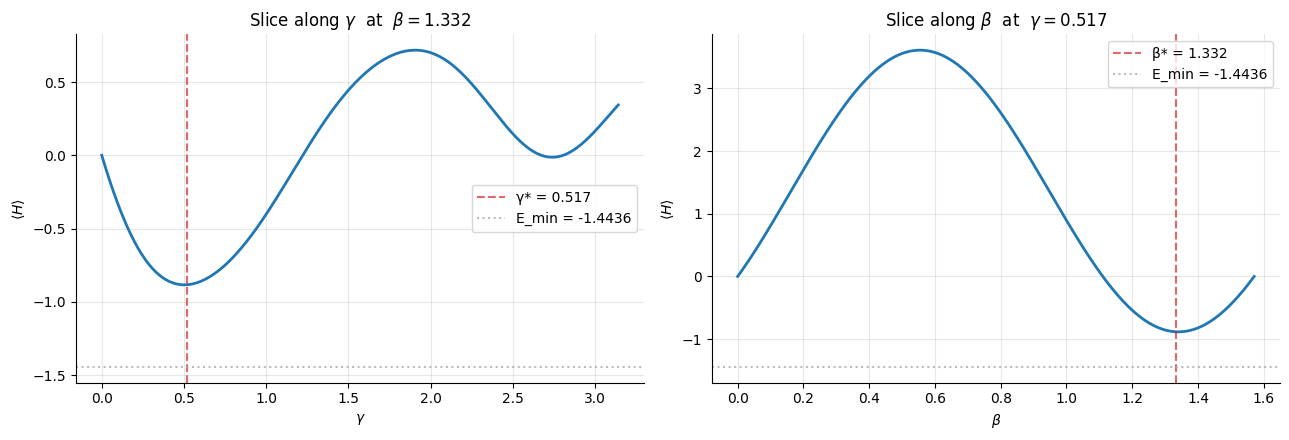

γ-slice minimum:  -0.883729  at γ = 0.5043
β-slice minimum:  -0.884417  at β = 1.3396


In [4]:
gammas_slice, energies_g = slice_along_gamma(H, beta_fixed=beta_grid, n_points=300)
betas_slice,  energies_b = slice_along_beta (H, gamma_fixed=gamma_grid, n_points=300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(gammas_slice, energies_g, color="#1f77b4", lw=2)
axes[0].axvline(gamma_grid, color="#d62728", linestyle="--", alpha=0.7,
                label=f"γ* = {gamma_grid:.3f}")
axes[0].axhline(E_GROUND, color="#aaaaaa", linestyle=":", alpha=0.8,
                label=f"E_min = {E_GROUND:+.4f}")
axes[0].set_xlabel(r"$\gamma$")
axes[0].set_ylabel(r"$\langle H \rangle$")
axes[0].set_title(rf"Slice along $\gamma$  at  $\beta = {beta_grid:.3f}$")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

axes[1].plot(betas_slice, energies_b, color="#1f77b4", lw=2)
axes[1].axvline(beta_grid, color="#d62728", linestyle="--", alpha=0.7,
                label=f"β* = {beta_grid:.3f}")
axes[1].axhline(E_GROUND, color="#aaaaaa", linestyle=":", alpha=0.8,
                label=f"E_min = {E_GROUND:+.4f}")
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel(r"$\langle H \rangle$")
axes[1].set_title(rf"Slice along $\beta$  at  $\gamma = {gamma_grid:.3f}$")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"γ-slice minimum:  {energies_g.min():+.6f}  at γ = {gammas_slice[np.argmin(energies_g)]:.4f}")
print(f"β-slice minimum:  {energies_b.min():+.6f}  at β = {betas_slice[np.argmin(energies_b)]:.4f}")

## 5. Refining: a zoomed sweep around the optimum

A fine-grained sweep on a smaller window around the grid minimum, useful for two purposes:

1. Getting a more accurate estimate of the true $(\gamma^\star, \beta^\star)$ at $p = 1$ without paying for a high-resolution sweep over the full $[0, \pi] \times [0, \pi/2]$ box.
2. Visualising the local *shape* of the optimum — is it a sharp valley, a broad basin, or something pathological with multiple sub-minima?

Zoom region: γ ∈ [0.267, 0.767], β ∈ [1.082, 1.571]
Refined minimum: γ = 0.5138, β = 1.3420, ⟨H⟩ = -0.884408
Coarse minimum:  γ = 0.5170, β = 1.3322, ⟨H⟩ = -0.883199
Refinement gain: +0.001208


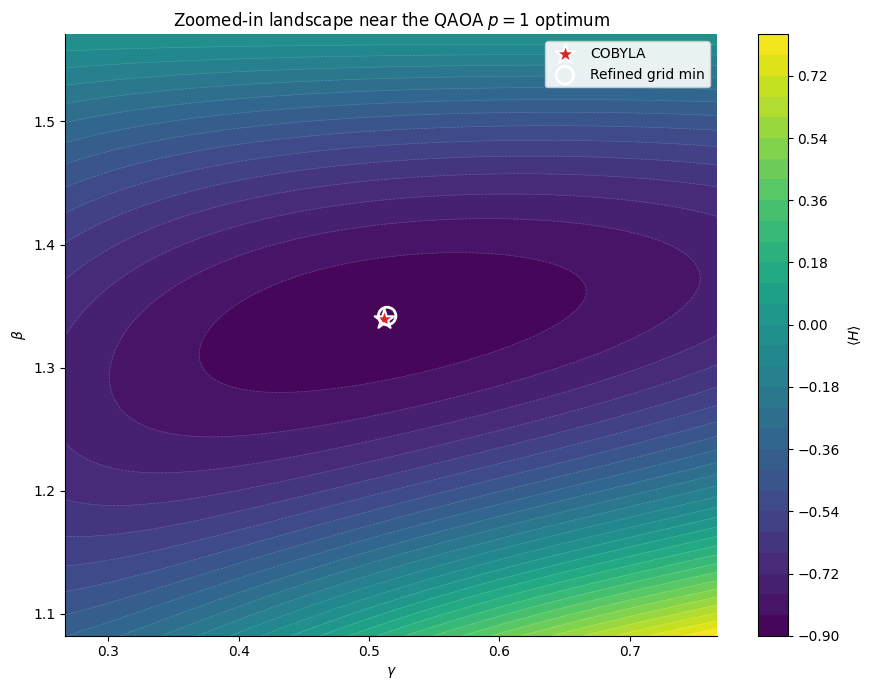

In [5]:
window = 0.25  # radians on each side

gamma_lo = max(0.0,        gamma_grid - window)
gamma_hi = min(np.pi,      gamma_grid + window)
beta_lo  = max(0.0,        beta_grid  - window)
beta_hi  = min(np.pi / 2,  beta_grid  + window)

land_zoom = sweep_p1(
    H,
    gamma_range=(gamma_lo, gamma_hi),
    beta_range =(beta_lo,  beta_hi),
    n_gamma=80, n_beta=80,
)
i, j, gamma_z, beta_z, energy_z = land_zoom.argmin()

print(f"Zoom region: γ ∈ [{gamma_lo:.3f}, {gamma_hi:.3f}], β ∈ [{beta_lo:.3f}, {beta_hi:.3f}]")
print(f"Refined minimum: γ = {gamma_z:.4f}, β = {beta_z:.4f}, ⟨H⟩ = {energy_z:+.6f}")
print(f"Coarse minimum:  γ = {gamma_grid:.4f}, β = {beta_grid:.4f}, ⟨H⟩ = {energy_grid:+.6f}")
print(f"Refinement gain: {energy_grid - energy_z:+.6f}")

fig, ax = plt.subplots(figsize=(9, 7))
G, B = np.meshgrid(land_zoom.gammas, land_zoom.betas, indexing="ij")
cf = ax.contourf(G, B, land_zoom.energies, levels=30, cmap="viridis")
ax.contour(G, B, land_zoom.energies, levels=30, colors="white", alpha=0.18, linewidths=0.5)

ax.scatter([GAMMA_COBYLA], [BETA_COBYLA],
           s=220, marker="*", color="#d62728", edgecolor="white", linewidth=1.5,
           zorder=10, label=f"COBYLA")
ax.scatter([gamma_z], [beta_z],
           s=160, marker="o", facecolor="none", edgecolor="white", linewidth=2.0,
           zorder=11, label=f"Refined grid min")

ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\beta$")
ax.set_title(r"Zoomed-in landscape near the QAOA $p=1$ optimum")
plt.colorbar(cf, ax=ax, label=r"$\langle H \rangle$")
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 6. Persist the landscape for later sessions

Save the coarse and zoomed grids — they're useful inputs for the noise/hardware comparison in upcoming sessions (e.g. plotting where a noisy-simulator sweep diverges from this clean landscape).

In [6]:
np.savez(
    DATA_PROCESSED / "p1_landscape.npz",
    gammas_coarse=land.gammas,
    betas_coarse=land.betas,
    energies_coarse=land.energies,
    gammas_zoom=land_zoom.gammas,
    betas_zoom=land_zoom.betas,
    energies_zoom=land_zoom.energies,
    gamma_grid_min=gamma_grid,
    beta_grid_min=beta_grid,
    energy_grid_min=energy_grid,
    gamma_zoom_min=gamma_z,
    beta_zoom_min=beta_z,
    energy_zoom_min=energy_z,
    cobyla_gamma=GAMMA_COBYLA,
    cobyla_beta=BETA_COBYLA,
    cobyla_energy=COBYLA_ENERGY,
)
print(f"Saved {(DATA_PROCESSED / 'p1_landscape.npz').relative_to(ROOT)}")

Saved data/processed/p1_landscape.npz


## Session 1 (Week 3) — wrap-up

The 2-D heatmap is the headline artefact and is suitable for the LinkedIn carousel and the blog post's hero image. Two practical takeaways:

- **COBYLA at $p = 1$ found the global minimum** (the star and the circle sit in the same valley). This validates the Session 3 result and gives us confidence to trust the higher-$p$ COBYLA runs even though we can't visually inspect their landscapes.
- **The deepest part of the $p = 1$ landscape sits well above the ground-state energy.** That's the $p = 1$ ceiling — a fundamental limit, not an optimiser failure. To approach the ground state we genuinely need more depth.

**Next session (Week 3, Session 2):** the first real hardware run on IBM Quantum. The plan: transpile the $p = 1$ QAOA circuit for one of the freely available 127-qubit IBM backends, submit the job, and have it sit in the queue while we work on something else. Expected wall time: 5–30 minutes of active work to submit, then queue wait of hours to days depending on the day.